# Customer Segmentation Analysis: BigQuery ML
This notebook pulls the final results from BigQuery to evaluate the K-means clusters and analyze **Segment Drift** between 2009 and 2011.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv(dotenv_path='../.env')

client = bigquery.Client()
sns.set_theme(style="whitegrid", palette="muted")


## 1. Load Scored Data
We pull the final scored tables with business labels.

In [ ]:
query_2009 = "SELECT * FROM `retail_segmentation.final_scored_2009_2010`"
df_09 = client.query(query_2009).to_dataframe()

query_2010 = "SELECT * FROM `retail_segmentation.final_scored_2010_2011`"
df_10 = client.query(query_2010).to_dataframe()

print(f"Loaded {len(df_09)} customers from 2009-2010")
print(f"Loaded {len(df_10)} customers from 2010-2011")


c:\Users\arq_c\Desktop\ds_projects\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 4285 customers from 2009-2010
Loaded 4334 customers from 2010-2011


## 2. Cluster Distribution (Year 1)
Visualizing the size of each business segment in the training period.

C:\Users\arq_c\AppData\Local\Temp\ipykernel_20984\4053616508.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


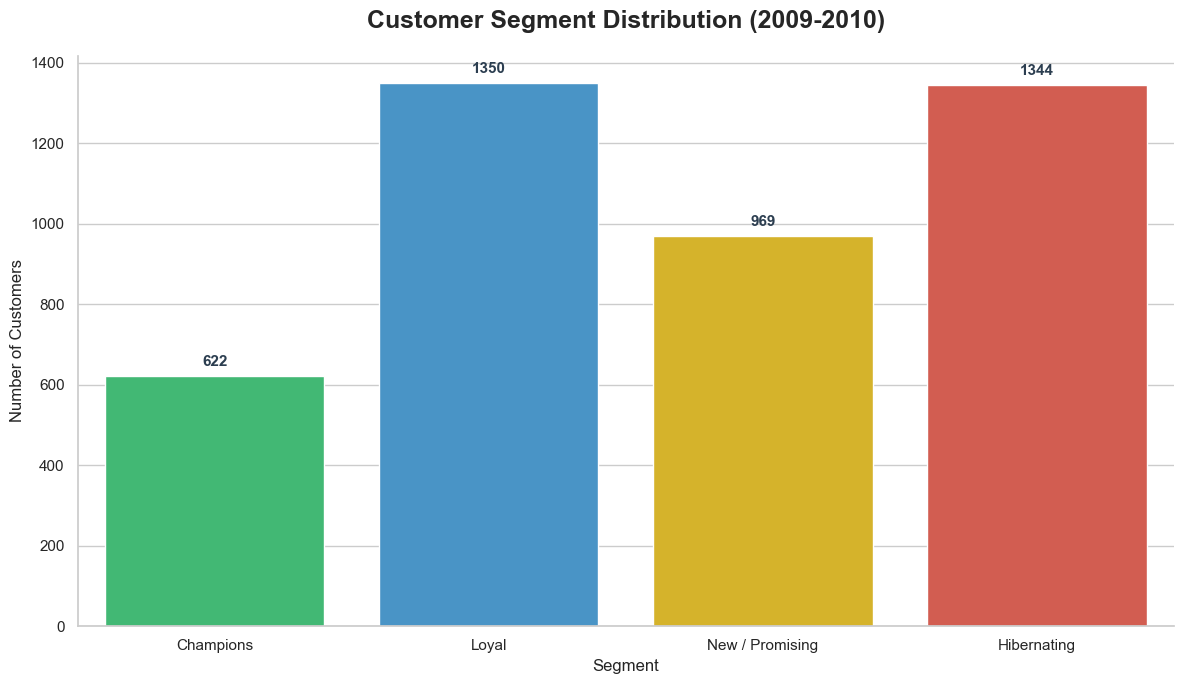

In [6]:
# Segment palette for business meaning
segment_colors = {
    'Champions': '#2ecc71',      # Emerald Green
    'Loyal': '#3498db',          # Peter River Blue
    'New / Promising': '#f1c40f', # Sunflower Yellow
    'Hibernating': '#e74c3c'     # Alizarin Red
}

plt.figure(figsize=(12, 7))
ax = sns.countplot(
    data=df_09, 
    x='segment_label', 
    order=['Champions', 'Loyal', 'New / Promising', 'Hibernating'],
    palette=segment_colors
)

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='#2c3e50')

plt.title('Customer Segment Distribution (2009-2010)', fontsize=18, pad=20, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12)
plt.xlabel('Segment', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()


## 3. Segment Drift Analysis
Comparing the percentage of customers in each segment over two years.

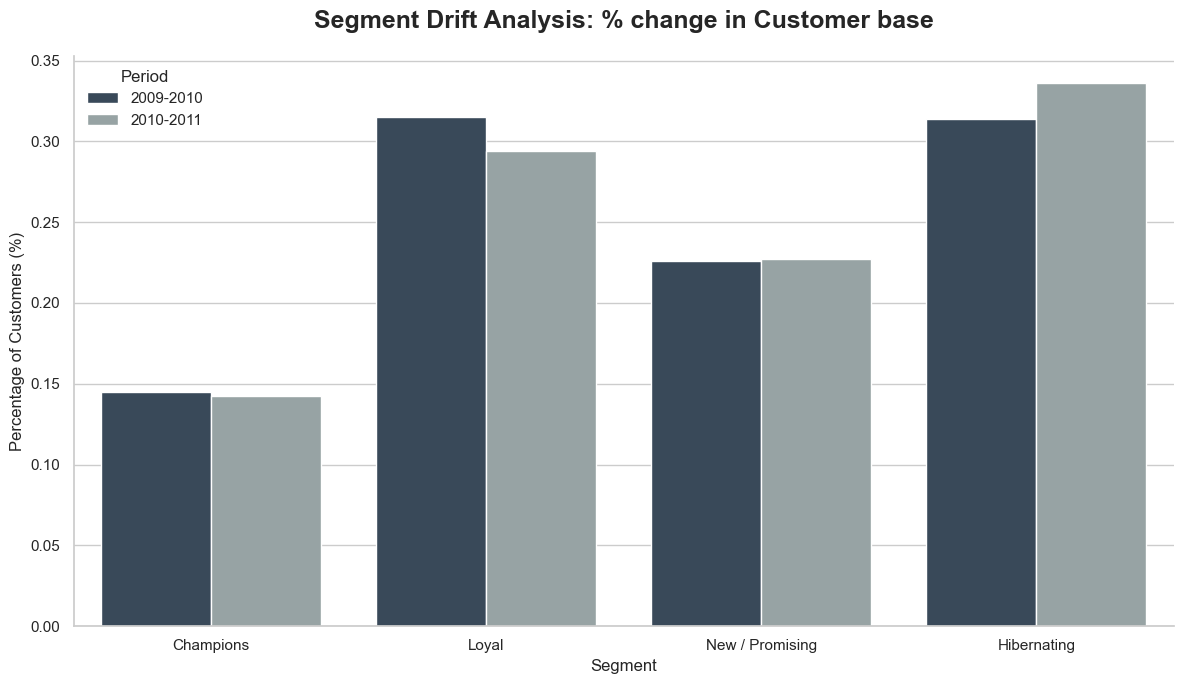

In [ ]:
dist_09 = df_09['segment_label'].value_counts(normalize=True).reset_index()
dist_09.columns = ['segment_label', 'percentage']
dist_09['year'] = '2009-2010'

dist_10 = df_10['segment_label'].value_counts(normalize=True).reset_index()
dist_10.columns = ['segment_label', 'percentage']
dist_10['year'] = '2010-2011'

drift_df = pd.concat([dist_09, dist_10])

plt.figure(figsize=(12, 7))
sns.barplot(
    data=drift_df, 
    x='segment_label', 
    y='percentage', 
    hue='year',
    order=['Champions', 'Loyal', 'New / Promising', 'Hibernating'],
    palette=['#34495e', '#95a5a6'] # Contrast years
)

plt.title('Segment Drift Analysis: % change in Customer base', fontsize=18, pad=20, fontweight='bold')
plt.ylabel('Percentage of Customers (%)', fontsize=12)
plt.xlabel('Segment', fontsize=12)
plt.legend(title='Period', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


## 4. RFM Feature Scattering
Visualizing the high-value 'Champions' vs others in the RFM space.

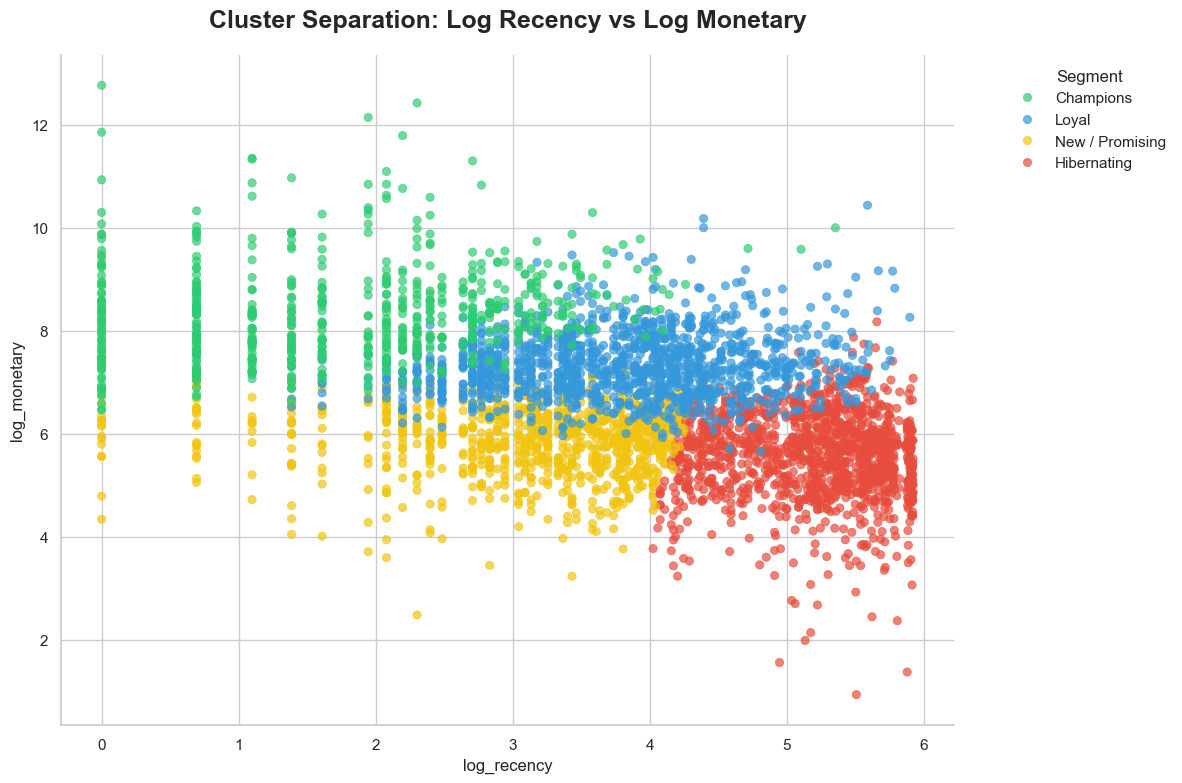

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_09, 
    x='log_recency', 
    y='log_monetary', 
    hue='segment_label', 
    hue_order=['Champions', 'Loyal', 'New / Promising', 'Hibernating'],
    palette=segment_colors, # Use consistent mapping
    alpha=0.7,
    edgecolor=None
)

plt.title('Cluster Separation: Log Recency vs Log Monetary', fontsize=18, pad=20, fontweight='bold')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


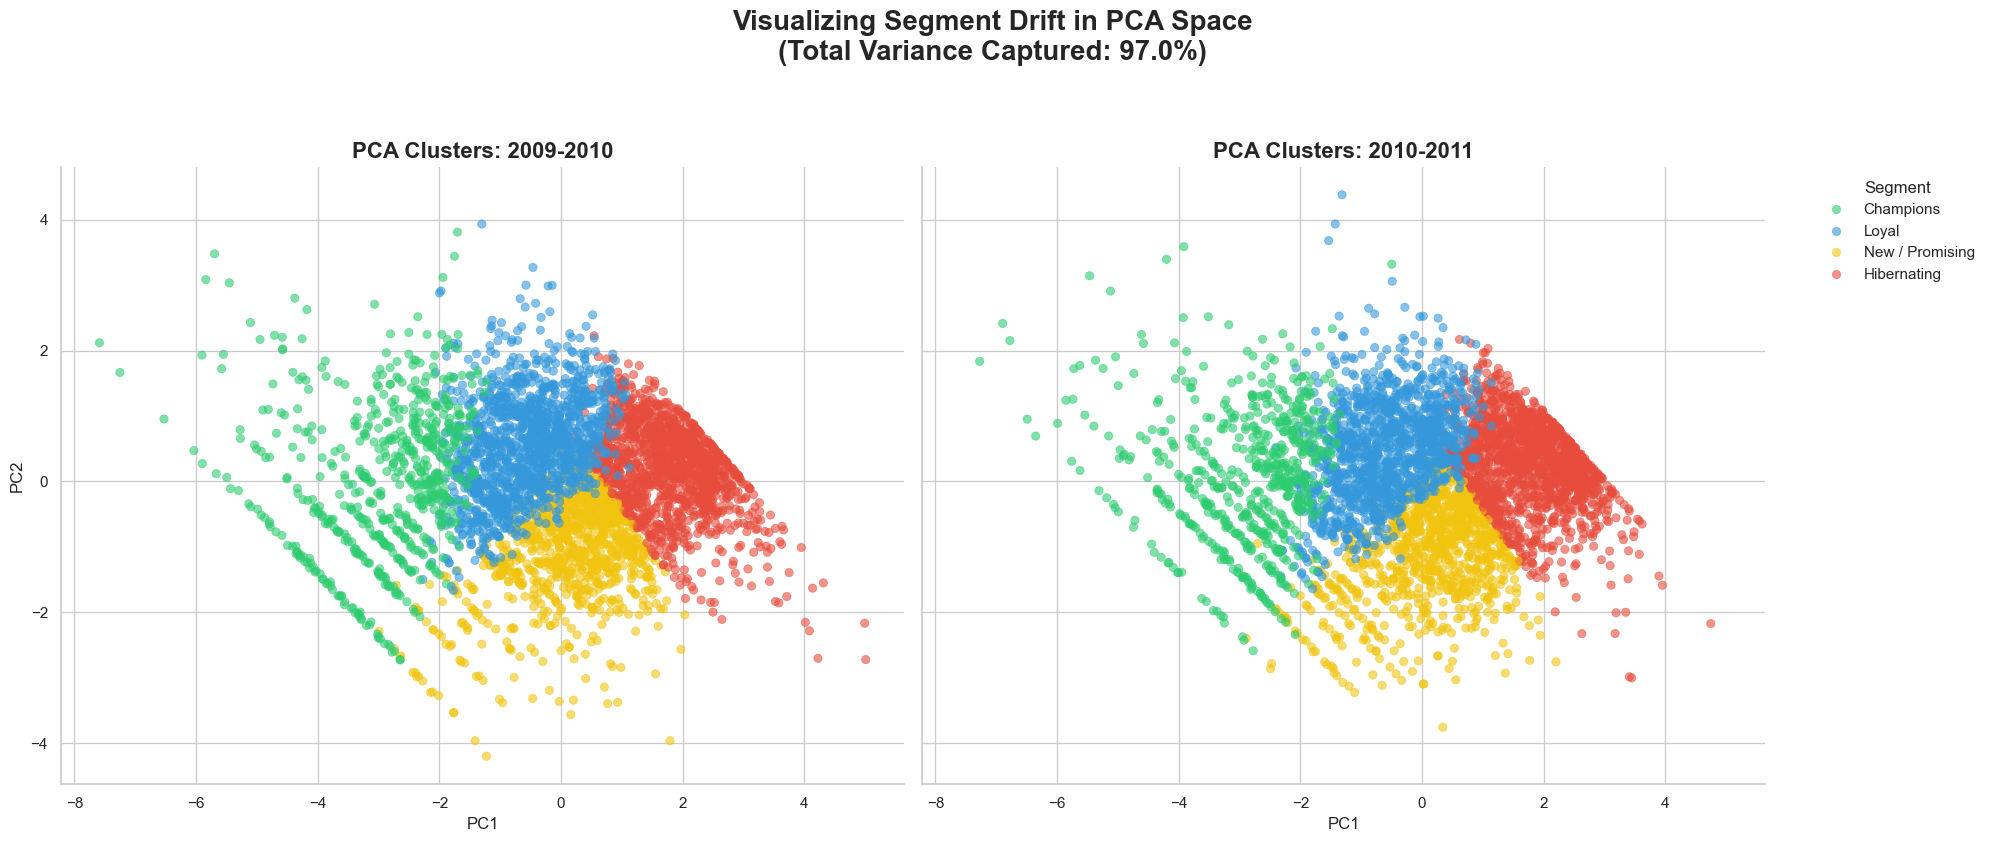

In [ ]:
from sklearn.decomposition import PCA

# 1. Prepare data and define features
features = ['log_monetary', 'log_frequency', 'log_recency']
hue_order = ['Champions', 'Loyal', 'New / Promising', 'Hibernating']

# 2. Fit PCA on 2009-2010 (Training) and transform both
pca = PCA(n_components=2)
pca.fit(df_09[features]) # Basis from training

pca_09 = pca.transform(df_09[features])
pca_10 = pca.transform(df_10[features])

# 3. Create helper dataframes for plotting
df_pca_09 = pd.DataFrame(pca_09, columns=['PC1', 'PC2'])
df_pca_09['segment_label'] = df_09['segment_label'].values
df_pca_09['year'] = '2009-2010'

df_pca_10 = pd.DataFrame(pca_10, columns=['PC1', 'PC2'])
df_pca_10['segment_label'] = df_10['segment_label'].values
df_pca_10['year'] = '2010-2011'

all_pca = pd.concat([df_pca_09, df_pca_10])

# 4. Plot Side-by-Side Comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, sharey=True)

for i, year in enumerate(['2009-2010', '2010-2011']):
    sns.scatterplot(
        data=all_pca[all_pca['year'] == year],
        x='PC1', y='PC2', 
        hue='segment_label',
        hue_order=hue_order,
        palette=segment_colors,
        alpha=0.6,
        edgecolor=None,
        ax=axes[i]
    )
    axes[i].set_title(f'PCA Clusters: {year}', fontsize=16, fontweight='bold')
    axes[i].get_legend().remove()
    sns.despine(ax=axes[i])

# Add common legend and title
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.suptitle(f'Visualizing Segment Drift in PCA Space\n(Total Variance Captured: {sum(pca.explained_variance_ratio_):.1%})', 
             fontsize=20, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()
